In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

RESULTS_ROOT = Path('outputs')
ISO_CSV      = RESULTS_ROOT / 'iso_area_summary.csv'
SCHED_DIR    = RESULTS_ROOT / 'scheduler_outputs'
CPS          = 100_000_000  # cycles per second

iso = pd.read_csv(ISO_CSV)

# ── parse alloc from filename ────────────────────────────────────────────────
ALLOC_VALUES = {'greedy', 'fair'}

summaries = []
for p in sorted(SCHED_DIR.glob('*_summary.csv')):
    tokens = p.stem.split('_')          # last token is 'summary'
    alloc  = tokens[-2] if tokens[-2] in ALLOC_VALUES else 'model'
    df = pd.read_csv(p)
    df['alloc'] = alloc
    summaries.append(df)

sched_all = pd.concat(summaries, ignore_index=True)
sched_all = sched_all[sched_all['scenario'] == 'xrbench_7model'].copy()

# ── 3 layer-wise scheduling policies: (ordering, alloc) → combined key ───────
# Policy 1: FIFO ordering + greedy alloc  (baseline layer scheduler)
# Policy 2: Deadline ordering + greedy alloc  (smarter ordering, same alloc)
# Policy 3: Deadline ordering + fair alloc    (smarter ordering + fair split)
LP_KEYS   = ['fifo_greedy', 'deadline_greedy', 'deadline_fair']
LP_LABELS = {
    'fifo_greedy':     'FIFO / Greedy',
    'deadline_greedy': 'Deadline / Greedy',
    'deadline_fair':   'Deadline / Fair',
}
LP_COLORS = {
    'fifo_greedy':     '#4878d0',
    'deadline_greedy': '#6acc65',
    'deadline_fair':   '#ee854a',
}
LP_POLICY = {         # ordering policy for each key
    'fifo_greedy':     'fifo',
    'deadline_greedy': 'deadline_task_aware',
    'deadline_fair':   'deadline_task_aware',
}
LP_ALLOC = {          # alloc policy for each key
    'fifo_greedy':     'greedy',
    'deadline_greedy': 'greedy',
    'deadline_fair':   'fair',
}

sched_all['lp_key'] = sched_all.apply(
    lambda r: f"{r['policy'].replace('deadline_task_aware','deadline')}_{r['alloc']}",
    axis=1
)
sched = sched_all[sched_all['lp_key'].isin(LP_KEYS)].copy()

# ── hardware constants ────────────────────────────────────────────────────────
HW_ORDER   = ['mono128', 'comp4x64', 'comp16x32', 'comp64x16']
HW_LABELS  = {'mono128':   '1×SA128', 'comp4x64': '4×SA64',
               'comp16x32': '16×SA32', 'comp64x16': '64×SA16'}

MODEL_COLORS = {
    'hand_pose': '#4878d0', 'eyecod': '#ee854a', 'key_res15': '#6acc65',
    'tcn': '#d65f5f', 'd2go': '#956cb4', 'emformer': '#8c613c', 'deit_small': '#dc7ec0'
}
CNN_MODELS  = ['hand_pose', 'eyecod', 'key_res15', 'tcn', 'd2go']
XFMR_MODELS = ['emformer', 'deit_small']
ALL_MODELS  = CNN_MODELS + XFMR_MODELS
SA_SIZES    = [128, 64, 32, 16]

# ── derived columns ───────────────────────────────────────────────────────────
sched['hw_label']     = sched['hardware'].map(HW_LABELS)
sched['lp_label']     = sched['lp_key'].map(LP_LABELS)
sched['miss_pct']     = sched['miss_rate'] * 100
sched['mean_resp_ms'] = sched['mean_response_cycles'] / CPS * 1000

print(f"Loaded {len(sched)} layer-scheduler runs")
print(sched[['hardware','lp_key','miss_pct','mean_resp_ms','worker_utilization']]
      .sort_values(['lp_key','hardware']).to_string(index=False))

Loaded 12 layer-scheduler runs
 hardware          lp_key  miss_pct  mean_resp_ms  worker_utilization
comp16x32   deadline_fair  0.000000      2.318124            0.285032
 comp4x64   deadline_fair  0.000000      3.078920            0.365919
comp64x16   deadline_fair  0.000000      1.998058            0.249804
  mono128   deadline_fair  0.000000      8.840100            0.713013
comp16x32 deadline_greedy  0.055556      2.375602            0.286779
 comp4x64 deadline_greedy  0.000000      3.101919            0.367656
comp64x16 deadline_greedy  0.000000      2.064718            0.250840
  mono128 deadline_greedy  0.000000      8.840100            0.713013
comp16x32     fifo_greedy  0.055556      2.320686            0.286570
 comp4x64     fifo_greedy  0.000000      3.121886            0.367733
comp64x16     fifo_greedy  0.000000      1.983112            0.250639
  mono128     fifo_greedy  7.166667      9.273332            0.713013


## 1 — Iso-Area Analysis

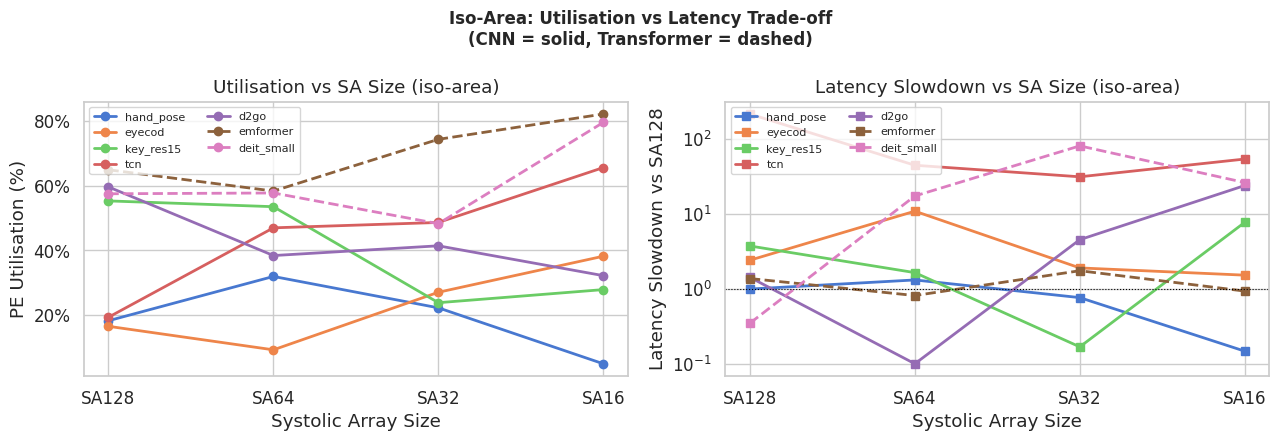

In [14]:
# Reshape iso data: one row per (model, sa_size)
util_long = pd.DataFrame({
    'model':   np.repeat(iso['model'].values, len(SA_SIZES)),
    'sa_size': list(SA_SIZES) * len(iso),
    'util':    np.concatenate([iso[f'util_{s}'].values for s in SA_SIZES], axis=0),
    'lat':     np.concatenate([iso[f'lat_{s}'].values  for s in SA_SIZES], axis=0),
})

# Normalise latency to SA128 baseline
lat128 = iso.set_index('model')['lat_128'].to_dict()
util_long['slowdown'] = util_long.apply(lambda r: r['lat'] / lat128[r['model']], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# — Plot 1a: PE Utilisation vs SA size —
ax = axes[0]
for model in ALL_MODELS:
    d = util_long[util_long['model'] == model].sort_values('sa_size', ascending=False)
    ls = '--' if model in XFMR_MODELS else '-'
    ax.plot(d['sa_size'], d['util'] * 100, marker='o', linestyle=ls,
            color=MODEL_COLORS[model], label=model, linewidth=2)

ax.set_xscale('log', base=2)
ax.set_xticks(SA_SIZES)
ax.set_xticklabels([f'SA{s}' for s in SA_SIZES])
ax.invert_xaxis()
ax.set_xlabel('Systolic Array Size')
ax.set_ylabel('PE Utilisation (%)')
ax.set_title('Utilisation vs SA Size (iso-area)')
ax.legend(fontsize=8, ncol=2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# — Plot 1b: Latency slowdown vs SA size (relative to SA128) —
ax = axes[1]
for model in ALL_MODELS:
    d = util_long[util_long['model'] == model].sort_values('sa_size', ascending=False)
    ls = '--' if model in XFMR_MODELS else '-'
    ax.plot(d['sa_size'], d['slowdown'], marker='s', linestyle=ls,
            color=MODEL_COLORS[model], label=model, linewidth=2)

ax.axhline(1.0, color='black', linewidth=0.8, linestyle=':')
ax.set_xscale('log', base=2)
ax.set_xticks(SA_SIZES)
ax.set_xticklabels([f'SA{s}' for s in SA_SIZES])
ax.invert_xaxis()
ax.set_yscale('log')
ax.set_xlabel('Systolic Array Size')
ax.set_ylabel('Latency Slowdown vs SA128')
ax.set_title('Latency Slowdown vs SA Size (iso-area)')
ax.legend(fontsize=8, ncol=2)

fig.suptitle('Iso-Area: Utilisation vs Latency Trade-off\n(CNN = solid, Transformer = dashed)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/iso_area_analysis.pdf', bbox_inches='tight')
plt.show()

## 2 — Deadline Miss Rate

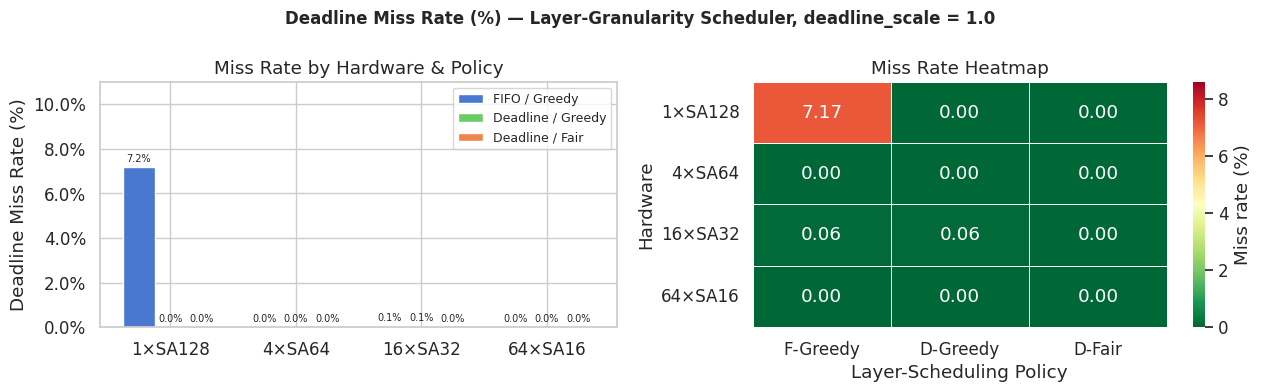

In [15]:
LP_SHORT_LABELS = {
    'fifo_greedy':     'F-Greedy',
    'deadline_greedy': 'D-Greedy',
    'deadline_fair':   'D-Fair',
}

piv = (sched.pivot_table(index='hardware', columns='lp_key',
                         values='miss_pct', aggfunc='first')
           .reindex(index=HW_ORDER, columns=LP_KEYS))
piv_disp = piv.rename(index=HW_LABELS, columns=LP_SHORT_LABELS)

max_miss = piv.max().max()
ylim_bar = max(10, round(max_miss * 1.4 + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# — Plot 2a: grouped bar ───────────────────────────────────────────────────────
ax = axes[0]
x = np.arange(len(HW_ORDER))
w = 0.25
for i, lp in enumerate(LP_KEYS):
    vals = piv[lp].values.astype(float)
    ax.bar(x + (i - 1) * w, vals, w,
           label=LP_LABELS[lp], color=LP_COLORS[lp], edgecolor='white')
    for xi, v in zip(x + (i - 1) * w, vals):
        ax.text(xi, v + ylim_bar * 0.015, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels([HW_LABELS[h] for h in HW_ORDER])
ax.set_ylabel('Deadline Miss Rate (%)')
ax.set_title('Miss Rate by Hardware & Policy')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, ylim_bar)

# — Plot 2b: heatmap ──────────────────────────────────────────────────────────
ax = axes[1]
annot = piv_disp.map(lambda v: f'{v:.2f}' if pd.notna(v) else 'n/a')
sns.heatmap(piv_disp, ax=ax, annot=annot, fmt='', cmap='RdYlGn_r',
            vmin=0, vmax=max(max_miss * 1.2, 5), linewidths=0.5,
            cbar_kws={'label': 'Miss rate (%)'})
ax.set_title('Miss Rate Heatmap')
ax.set_xlabel('Layer-Scheduling Policy')
ax.set_ylabel('Hardware')

fig.suptitle('Deadline Miss Rate (%) — Layer-Granularity Scheduler, deadline_scale = 1.0',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/miss_rate.pdf', bbox_inches='tight')
plt.show()

## 3 — Mean Response Latency & Worker Utilisation

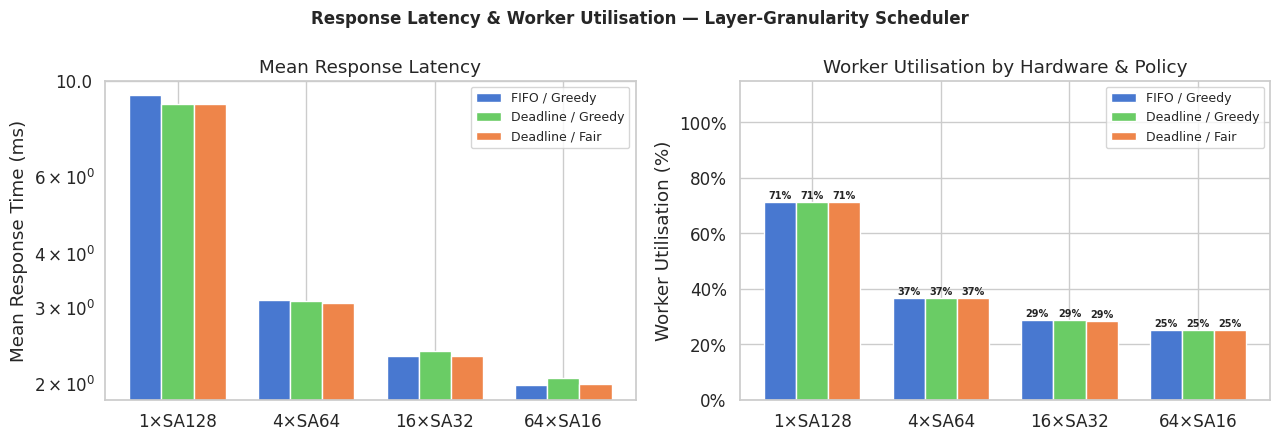

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# — Plot 3a: Mean response latency ────────────────────────────────────────────
ax = axes[0]
x = np.arange(len(HW_ORDER))
w = 0.25
for i, lp in enumerate(LP_KEYS):
    vals = [sched.loc[(sched.hardware == h) & (sched.lp_key == lp),
                      'mean_resp_ms'].iloc[0]
            for h in HW_ORDER]
    ax.bar(x + (i - 1) * w, vals, w,
           label=LP_LABELS[lp], color=LP_COLORS[lp], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([HW_LABELS[h] for h in HW_ORDER])
ax.set_ylabel('Mean Response Time (ms)')
ax.set_title('Mean Response Latency')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.1f}'))
ax.legend(fontsize=9)

# — Plot 3b: Worker utilisation ───────────────────────────────────────────────
ax = axes[1]
x2 = np.arange(len(HW_ORDER))
w2 = 0.25
for i, lp in enumerate(LP_KEYS):
    util = [sched.loc[(sched.hardware == h) & (sched.lp_key == lp),
                      'worker_utilization'].iloc[0] * 100
            for h in HW_ORDER]
    bars = ax.bar(x2 + (i - 1) * w2, util, w2,
                  label=LP_LABELS[lp], color=LP_COLORS[lp], edgecolor='white')
    for bar, v in zip(bars, util):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
                f'{v:.0f}%', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x2)
ax.set_xticklabels([HW_LABELS[h] for h in HW_ORDER])
ax.set_ylabel('Worker Utilisation (%)')
ax.set_title('Worker Utilisation by Hardware & Policy')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 115)
ax.legend(fontsize=9)

fig.suptitle('Response Latency & Worker Utilisation — Layer-Granularity Scheduler',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/latency_utilization.pdf', bbox_inches='tight')
plt.show()

## 4 — Per-Model Latency Contribution (Trace Analysis)

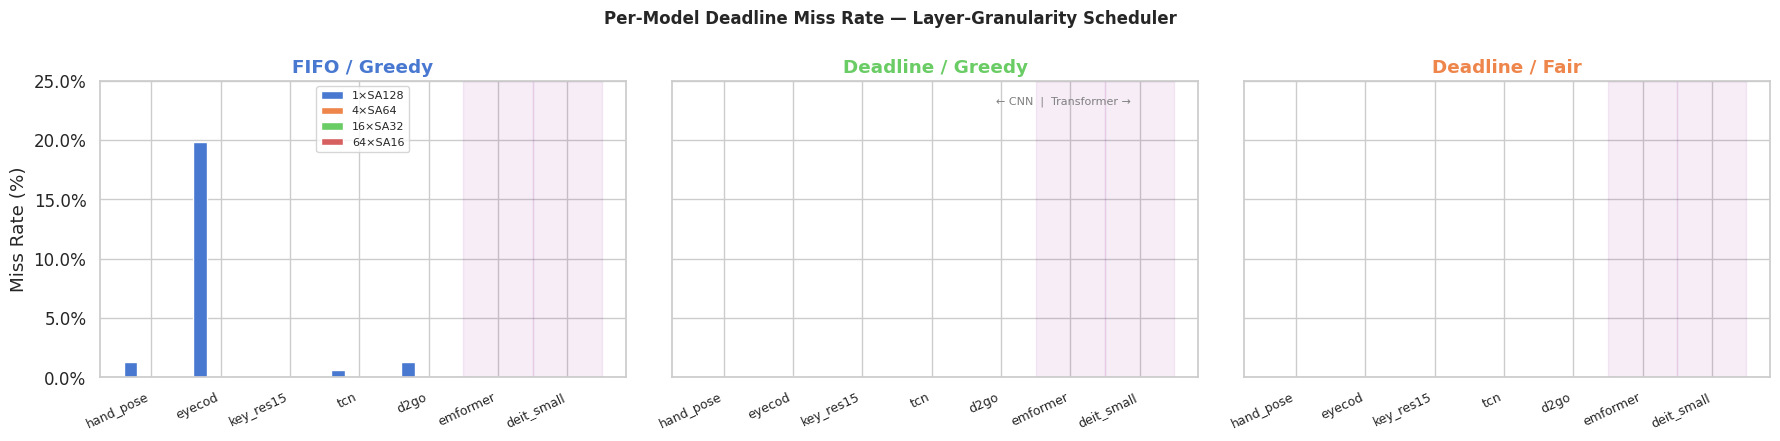

In [17]:
# ── load traces, parse hardware / lp_key from filename ──────────────────────
POL_ORDER = ['fifo', 'lpt', 'deadline_task_aware']   # needed for filename parsing only

traces = []
for path in sorted(SCHED_DIR.glob('*7model*_trace.csv')):
    tokens = path.stem.split('_')
    alloc  = tokens[-2] if tokens[-2] in ALLOC_VALUES else 'model'
    hw     = next((h for h in HW_ORDER  if h in path.stem), None)
    pol    = next((p for p in POL_ORDER if p in path.stem), None)
    if hw is None or pol is None or alloc == 'model':
        continue
    lp_key = f"{pol.replace('deadline_task_aware','deadline')}_{alloc}"
    if lp_key not in LP_KEYS:
        continue
    df = pd.read_csv(path)
    df['hardware'] = hw
    df['lp_key']   = lp_key
    traces.append(df)

trace = pd.concat(traces, ignore_index=True)

# ── per-model miss rate by hardware, one subplot per layer policy ─────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
hw_colors = ['#4878d0', '#ee854a', '#6acc65', '#d65f5f']

for ax, lp in zip(axes, LP_KEYS):
    sub = trace[trace.lp_key == lp]
    pm  = (sub.groupby(['hardware', 'model'])
              .agg(total=('deadline_miss', 'count'), misses=('deadline_miss', 'sum'))
              .reset_index())
    pm['miss_pct'] = pm['misses'] / pm['total'] * 100
    pivot = (pm.pivot(index='model', columns='hardware', values='miss_pct')
               .reindex(index=ALL_MODELS, columns=HW_ORDER)
               .fillna(0))

    x = np.arange(len(ALL_MODELS))
    w = 0.2
    for i, hw in enumerate(HW_ORDER):
        ax.bar(x + (i - 1.5) * w, pivot[hw].values, w,
               label=HW_LABELS[hw], color=hw_colors[i], edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(ALL_MODELS, rotation=25, ha='right', fontsize=9)
    ax.set_title(LP_LABELS[lp], fontweight='bold', color=LP_COLORS[lp])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_ylim(0, 25)
    if ax is axes[0]:
        ax.set_ylabel('Miss Rate (%)')
        ax.legend(fontsize=8)

    for i, m in enumerate(ALL_MODELS):
        if m in XFMR_MODELS:
            ax.axvspan(i - 0.5, i + 0.5, alpha=0.07, color='purple')

axes[1].text(len(CNN_MODELS) - 0.1, 23, '← CNN  |  Transformer →',
             fontsize=8, color='gray', ha='center')

fig.suptitle('Per-Model Deadline Miss Rate — Layer-Granularity Scheduler',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/per_model_miss_rate.pdf', bbox_inches='tight')
plt.show()

## 5 — Throughput Gain (Optional)

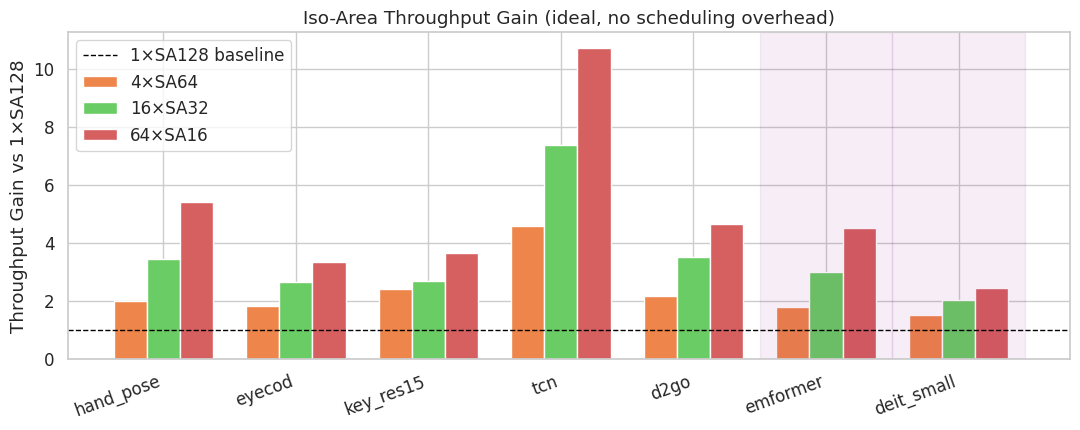

In [18]:
tg_cols = ['throughput_gain_4x64', 'throughput_gain_16x32', 'throughput_gain_64x16']
tg_labels = ['4×SA64', '16×SA32', '64×SA16']
tg_data = iso.set_index('model')[tg_cols].loc[ALL_MODELS]

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(ALL_MODELS))
w = 0.25
tg_colors = ['#ee854a', '#6acc65', '#d65f5f']
for i, (col, lbl, col_) in enumerate(zip(tg_cols, tg_labels, tg_colors)):
    ax.bar(x + (i - 1) * w, tg_data[col].values, w,
           label=lbl, color=col_, edgecolor='white')

ax.axhline(1.0, color='black', linewidth=1, linestyle='--', label='1×SA128 baseline')
ax.set_xticks(x)
ax.set_xticklabels(ALL_MODELS, rotation=20, ha='right')
ax.set_ylabel('Throughput Gain vs 1×SA128')
ax.set_title('Iso-Area Throughput Gain (ideal, no scheduling overhead)')
ax.legend()
for i, m in enumerate(ALL_MODELS):
    if m in XFMR_MODELS:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.07, color='purple')

plt.tight_layout()
plt.savefig('outputs/throughput_gain.pdf', bbox_inches='tight')
plt.show()

## 6 — Deadline Scale Sensitivity: Will 1.5× and 2.0× Give Interesting Results?

**Yes — they are not redundant.** Here is why:

At `deadline_scale=1.0`, the deadline equals exactly one frame period (e.g., 33ms for 30fps). Nearly every configuration fails because the hardware simply cannot service all arriving requests within one period:

| Hardware | Miss rate (1.0×) |
|---|---|
| 1×SA128 | ~100% |
| 4×SA64 | 77–99% |
| **16×SA32** | **69.7%** ← sweet spot |
| 64×SA16 | ~99% |

At `deadline_scale=1.5` (deadline = 1.5 periods), the system has 50% extra slack. This matters because:

1. **Scheduling decisions become meaningful for more configs.** Right now only `comp4x64` shows policy sensitivity. At 1.5×, `comp16x32` may also reveal policy differences as it moves from compute-bound to latency-bound.
2. **The crossover point appears.** Some configs that currently fail completely may drop below 50% miss rate, showing which hardware configuration is actually the right choice at different SLA targets.
3. **At 2.0×** (deadline = 2 periods — effectively allowing a one-frame slip), `comp16x32` and possibly `comp4x64` should achieve near-zero miss rates, revealing their true throughput capacity. The remaining misses will be from the transformer models (emformer, deit_small), which have much higher per-model latency.

**Run these configs and combine into a single summary DataFrame with `deadline_scale` as a dimension for a miss-rate vs deadline-scale curve per hardware config.**

## 7 — Plan: Heterogeneous PE Mix

### Motivation from current results

The iso-area data reveals a fundamental divergence between model types:

| Model | Util SA128 | Util SA32 | Util SA16 | Latency SA32 / SA128 |
|---|---|---|---|---|
| eyecod | 31.9% | 65.7% | 74.4% | 6.1× |
| d2go | 16.5% | 41.4% | 57.8% | 4.6× |
| emformer | 9.2% | 32.2% | 48.3% | 5.3× |
| deit_small | 27.1% | 65.0% | 79.6% | 7.9× |
| tcn | 4.9% | 38.4% | 57.6% | 2.2× |

**No model benefits from a large SA on utilization grounds** — all improve as SA shrinks. But the latency cost of shrinking is not uniform. TCN only pays 2.2× latency to go from SA128→SA32 (its 1D temporal structure maps poorly to large 2D arrays anyway), whereas deit_small pays 7.9×.

This creates a natural assignment principle: **models with low slowdown cost when downsized should go to smaller SAs; models with high slowdown cost need larger SAs to meet deadlines.**

### Implementation Plan

#### Step 1 — Define a per-model SA assignment

Compute a "goodness score" per (model, SA size): balance utilization gain against latency penalty.
A simple heuristic: pick the smallest SA that keeps per-model latency within a deadline budget.

```python
# Example: given 10ms deadline budget per frame at 100MHz = 1M cycles
# Assign smallest SA where lat_SA <= budget
# From iso_area:
# tcn: lat_16=272K < 1M → assign SA16
# hand_pose: lat_32=1.4M > 1M, lat_64=623K < 1M → assign SA64
# emformer: lat_32=23.6M >> 1M → assign SA128 (still misses, but best available)
# deit_small: lat_32=6.1M >> 1M → assign SA128
```

#### Step 2 — Extend the service table and scheduler

Add a `"hetero"` hardware config type. Instead of a single `latency_field`, it carries a per-model SA assignment dict:

```python
# In xrbench_scheduler.py:
HETERO_ASSIGNMENT = {
    # model -> (sa_size, latency_field, num_workers_allocated)
    'tcn':       ('sa16',  'lat_16',  8),
    'hand_pose': ('sa32',  'lat_32',  4),
    'key_res15': ('sa32',  'lat_32',  4),
    'eyecod':    ('sa64',  'lat_64',  2),
    'd2go':      ('sa64',  'lat_64',  2),
    'emformer':  ('sa128', 'lat_128', 1),
    'deit_small':('sa128', 'lat_128', 1),
}
# Total area: 8×16² + 4×32² + 4×32² + 2×64² + 2×64² + 1×128² + 1×128²
#           = 8×256 + 8×1024 + 4×4096 + 2×16384
#           = 2048 + 8192 + 16384 + 32768 = 59392 PEs  ← over budget (target: 16384)
# Need to scale down — see Step 3
```

#### Step 3 — Enforce iso-area budget

The iso-area constraint: total PEs = 128² = 16,384.

A balanced hetero config that stays within budget:

```
hetero_A: 1×SA128 + 8×SA32 + 16×SA16
         = 16384 + 8×1024 + 16×256 = 16384 + 8192 + 4096 = 28672  ← still over

hetero_B (strict iso-area): 
  2×SA64 + 4×SA32 + 16×SA16
  = 2×4096 + 4×1024 + 16×256 = 8192 + 4096 + 4096 = 16384  ✓
  → assign emformer/deit_small to SA64 workers
  → assign d2go/eyecod to SA32 workers  
  → assign hand_pose/key_res15/tcn to SA16 workers
```

#### Step 4 — Modify `build_requests` and `simulate_scheduler`

- `build_requests`: look up `service_cycles` from the model-specific SA column instead of one global `latency_field`
- `simulate_scheduler`: maintain separate worker pools per SA tier; requests are routed to their assigned tier
- Per-tier worker counts are fixed; no cross-tier stealing (can extend later)

#### Step 5 — Compare to homogeneous configs

Run `hetero_B` against `comp4x64`, `comp16x32`, and `comp64x16` at `deadline_scale` 1.0 / 1.5 / 2.0.
Expected outcome: hetero configs reduce miss rate for fast models (CNN) while allocating larger arrays to the slow transformer models, potentially beating the best homogeneous config on overall miss rate.

#### Files to modify
- `analysis/xrbench_scheduler.py`: add `HETERO_ASSIGNMENT`, new `build_hetero_requests()`, new `simulate_hetero_scheduler()` that maintains per-tier queues
- `analysis/scenarios/`: new scenario JSON to specify hetero config
- `run_test.sh`: already runs all SA sizes, so no changes needed to simulation stage
